In [1]:
import pandas as pd
import numpy as np
from functions import *
from sklearn.utils import shuffle
X_train_orig = pd.read_csv('../data/X_train.csv', index_col='id')
X_train_filtered = filter_signal(X_train_orig)
X_test_orig = pd.read_csv('../data/X_test.csv', index_col='id')
X_test_filtered = filter_signal(X_test_orig)
y_train_orig = pd.read_csv('../data/y_train.csv', index_col='id')

In [2]:
print("Median number of entries in each times series: ", np.median(np.sum(X_train_filtered.notna(), axis=1)))
print("Minimum number of entries in each times series: ", np.min(np.sum(X_train_filtered.notna(), axis=1)))
print("Size of training data: ", len(X_train_orig))
print(y_train_orig.value_counts())

Median number of entries in each times series:  8370.0
Minimum number of entries in each times series:  2490
Size of training data:  5117
y
0    3030
2    1474
1     443
3     170
dtype: int64


In [3]:
#Padding the sequence with the values in last row to max length
to_pad = 8400 # cut the sequence and impute the missing entries until all have this length
steps = 20 # to reduce time series length on every timepoint is taken
split = 4000 # to create test set with known label
n_1 = 700 # for upsampling
n_2 = 2000 
n_3 = 500

# choose the data to actually train on (after padding)
X_train = X_train_filtered 
X_test = X_test_filtered
y_train = y_train_orig

In [4]:
# shuffle data
X_train, y_train = shuffle(X_train, y_train, random_state=42)

X_train_padded = pd.DataFrame(np.ones((len(X_train),to_pad)))
for i in range(len(X_train)):
    one_seq = X_train.iloc[i,0:to_pad].dropna()
    len_one_seq = len(one_seq)
    last_val = one_seq[-1]
    n = to_pad - len_one_seq
   
    to_concat = np.repeat(one_seq[-1], n)
    new_one_seq = np.concatenate([one_seq, to_concat])
    X_train_padded.iloc[i,:] = new_one_seq
X_train_padded = X_train_padded.iloc[:,::steps]

X_test_padded = pd.DataFrame(np.ones((len(X_test),to_pad)))
for i in range(len(X_test)):
    one_seq = X_test.iloc[i,0:to_pad].dropna()
    len_one_seq = len(one_seq)
    last_val = one_seq[-1]
    n = to_pad - len_one_seq
   
    to_concat = np.repeat(one_seq[-1], n)
    new_one_seq = np.concatenate([one_seq, to_concat])
    X_test_padded.iloc[i,:] = new_one_seq
X_test_padded = X_test_padded.iloc[:,::steps]

# creat test set with labels
test = X_train_padded.iloc[split:,:] #  X_train.iloc[split:,:]
test_target = y_train.iloc[split:,:]
train = X_train_padded.iloc[:split,:] #  X_train.iloc[:split,:]
train_target = y_train.iloc[:split]

# validation sample actually not needed for second model
# from sklearn.model_selection import train_test_split
# train, validation, train_target, validation_target = train_test_split(X_train_padded, y_train, test_size=0.33, random_state=42)

# balance classes
# from sklearn.utils import resample
# df_1=train[np.array(train_target["y"]==1)]
# df_2=train[np.array(train_target["y"]==2)]
# df_3=train[np.array(train_target["y"]==3)]
# df_0=train[np.array(train_target["y"]==0)]

# df_1_upsample=resample(df_1,replace=True,n_samples=n_1,random_state=123)
# df_2_upsample=resample(df_2,replace=True,n_samples=n_2,random_state=124)
# df_3_upsample=resample(df_3,replace=True,n_samples=n_3,random_state=125)

# train=pd.concat([df_0,df_1_upsample,df_2_upsample,df_3_upsample],axis=0)
# train_target=pd.DataFrame([0]*len(df_0)+[1]*n_1+[2]*n_2+[3]*n_3)

# shuffle data
idx = np.random.permutation(len(train))
train = train.iloc[idx]
train_target = train_target.iloc[idx]

# get data in right dimension
train = np.array(train).reshape((train.shape[0], train.shape[1], 1))
# validation = np.array(validation).reshape((validation.shape[0], validation.shape[1], 1))
test = np.array(test).reshape((test.shape[0], test.shape[1], 1))

In [5]:
print(train_target.value_counts())
print(test_target.value_counts())

y
0    2375
2    1163
1     327
3     135
dtype: int64
y
0    655
2    311
1    116
3     35
dtype: int64


In [6]:
# cnn lstm model
from keras.models import Sequential
from keras.layers import Dense, Activation, Add, Softmax, Flatten, Normalization, Conv1D, MaxPooling1D
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers import LSTM
from keras.layers import TimeDistributed
from keras.layers import Normalization
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.optimizers import Adam
from keras.models import load_model
from keras.callbacks import ModelCheckpoint

In [7]:
# classes = len(np.unique(train_target))

# model = Sequential()
# model.add(LSTM(50, input_shape=(train.shape[1], 1)))
# model.add(Dropout(0.5))
# model.add(Dense(100, activation='relu'))
# model.add(Dense(classes, activation='softmax'))
# model.summary()

In [8]:
# adam = Adam(learning_rate=0.001)
# chk = ModelCheckpoint('best_model.pkl', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
# model.compile(loss='sparse_categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
# model.fit(train, train_target, epochs=10, batch_size=200, callbacks=[chk], validation_data=(validation,validation_target))


In [9]:
# #loading the model and checking accuracy on the test data
# model = load_model('best_model.pkl')

# from sklearn.metrics import f1_score
# predict_x=model.predict(test) 
# classes_x=np.argmax(predict_x,axis=1)
# f1_score(test_target, classes_x, average='micro')

In [10]:
from tensorflow import keras
def make_CNN(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(normalisation_layer) 
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    conv2 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)
    
    conv3 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)

    conv4 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv3)
    conv4 = keras.layers.BatchNormalization()(conv4)
    conv4 = keras.layers.ReLU()(conv4)

    # conv5 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv4)
    # conv5 = keras.layers.BatchNormalization()(conv5)
    # conv5 = keras.layers.ReLU()(conv5)

    # conv6 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv5)
    # conv6 = keras.layers.BatchNormalization()(conv6)
    # conv6 = keras.layers.ReLU()(conv6)

    # conv7 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv6)
    # conv7 = keras.layers.BatchNormalization()(conv7)
    # conv7 = keras.layers.ReLU()(conv7)

    gap = keras.layers.GlobalAveragePooling1D()(conv4)

    dense1 = keras.layers.Dense(50, activation='relu')(gap)
    dense2 = keras.layers.Dense(50, activation='relu')(dense1)
    dropout2 = keras.layers.Dropout(0.5)(dense2)
    dense3 = keras.layers.Dense(50, activation='relu')(dropout2)
    # dropout = keras.layers.Dropout(0.5)(dense2)

    output_layer = keras.layers.Dense(4, activation="softmax")(dense3)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)

In [11]:
def make_arvix(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)
    C = Conv1D(filters=32, kernel_size=5, strides=1)(normalisation_layer)

    C11 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(C)
    A11 = Activation("relu")(C11)
    C12 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A11)
    S11 = Add()([C12, C])
    A12 = Activation("relu")(S11)
    M11 = MaxPooling1D(pool_size=5, strides=2)(A12)


    C21 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M11)
    A21 = Activation("relu")(C21)
    C22 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A21)
    S21 = Add()([C22, M11])
    A22 = Activation("relu")(S21) # S21?
    M21 = MaxPooling1D(pool_size=5, strides=2)(A22)


    C31 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M21)
    A31 = Activation("relu")(C31)
    C32 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A31)
    S31 = Add()([C32, M21])
    A32 = Activation("relu")(S31)
    M31 = MaxPooling1D(pool_size=5, strides=2)(A32)


    C41 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M31)
    A41 = Activation("relu")(C41)
    C42 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A41)
    S41 = Add()([C42, M31])
    A42 = Activation("relu")(S41)
    M41 = MaxPooling1D(pool_size=5, strides=2)(A42)


    C51 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(M41)
    A51 = Activation("relu")(C51)
    C52 = Conv1D(filters=32, kernel_size=5, strides=1, padding='same')(A51)
    S51 = Add()([C52, M41])
    A52 = Activation("relu")(S51)
    M51 = MaxPooling1D(pool_size=5, strides=2)(A52)

    F1 = Flatten()(M51)

    D1 = Dense(32)(F1)
    A6 = Activation("relu")(D1)
    D2 = Dense(32)(A6)
    D3 = Dense(4)(D2)
    output_layer = Softmax()(D3)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)

In [12]:
def make_LSTM(input_shape):
    input_layer = keras.layers.Input(input_shape)
    normalisation_layer = Normalization()(input_layer)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=10, padding="same", kernel_regularizer='l2')(normalisation_layer) 
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    # conv2 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv1)
    # conv2 = keras.layers.BatchNormalization()(conv2)
    # conv2 = keras.layers.ReLU()(conv2)
    
    # conv3 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv2)
    # conv3 = keras.layers.BatchNormalization()(conv3)
    # conv3 = keras.layers.ReLU()(conv3)

    # conv4 = keras.layers.Conv1D(filters=64, kernel_size=5, padding="same", kernel_regularizer='l2')(conv3)
    # conv4 = keras.layers.BatchNormalization()(conv4)
    # conv4 = keras.layers.ReLU()(conv4)

    gap = keras.layers.MaxPooling1D(pool_size=2)(conv1)

    LSTM1 = keras.layers.LSTM(50)(gap)

    dense1 = keras.layers.Dense(50, activation='relu')(LSTM1)
    dense2 = keras.layers.Dense(50, activation='relu')(dense1)

    output_layer = keras.layers.Dense(4, activation="softmax")(dense2)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)


In [13]:
model1= make_CNN(input_shape=train.shape[1:]) # make_CNN(input_shape=train.shape[1:])
# keras.utils.plot_model(model, show_shapes=True)
model1.summary()

Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 420, 1)]          0         
_________________________________________________________________
normalization (Normalization (None, 420, 1)            3         
_________________________________________________________________
conv1d (Conv1D)              (None, 420, 64)           384       
_________________________________________________________________
batch_normalization (BatchNo (None, 420, 64)           256       
_________________________________________________________________
re_lu (ReLU)                 (None, 420, 64)           0         
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 420, 64)           20544     
______________________________________________

2021-12-06 08:23:25.359423: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2021-12-06 08:23:25.359599: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [14]:
epochs = 500
batch_size = 32

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.00001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model1.fit(
    train,
    train_target,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

2021-12-06 08:23:25.534524: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)
2021-12-06 08:23:25.534732: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Epoch 1/500


2021-12-06 08:23:25.866476: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


 99/100 [============================>.] - ETA: 0s - loss: 1.8050 - sparse_categorical_accuracy: 0.5938

2021-12-06 08:23:28.012691: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


100/100 [==============================] - 3s 20ms/step - loss: 1.7983 - sparse_categorical_accuracy: 0.5944 - val_loss: 1.3671 - val_sparse_categorical_accuracy: 0.5962
Epoch 2/500
100/100 [==============================] - 2s 17ms/step - loss: 1.0697 - sparse_categorical_accuracy: 0.6250 - val_loss: 1.2432 - val_sparse_categorical_accuracy: 0.5913
Epoch 3/500
100/100 [==============================] - 2s 18ms/step - loss: 0.9560 - sparse_categorical_accuracy: 0.6331 - val_loss: 0.9844 - val_sparse_categorical_accuracy: 0.5962
Epoch 4/500
100/100 [==============================] - 2s 19ms/step - loss: 0.9248 - sparse_categorical_accuracy: 0.6344 - val_loss: 0.9496 - val_sparse_categorical_accuracy: 0.6025
Epoch 5/500
100/100 [==============================] - 2s 18ms/step - loss: 0.9136 - sparse_categorical_accuracy: 0.6341 - val_loss: 0.9534 - val_sparse_categorical_accuracy: 0.5962
Epoch 6/500
100/100 [==============================] - 2s 17ms/step - loss: 0.8955 - sparse_categorica

In [15]:
model = keras.models.load_model("best_model.h5")

test_loss, test_acc = model.evaluate(test,test_target)

print("Test accuracy", test_acc)
print("Test loss", test_loss)

15/35 [===========>..................] - ETA: 0s - loss: 0.6869 - sparse_categorical_accuracy: 0.7458

2021-12-06 08:29:01.481267: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


35/35 [==============================] - 0s 9ms/step - loss: 0.6562 - sparse_categorical_accuracy: 0.7520
Test accuracy 0.7520143389701843
Test loss 0.6562365293502808


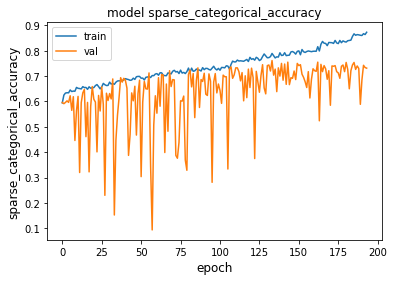

In [16]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [17]:
from sklearn.metrics import f1_score
predict_x=model.predict(test) 
classes_x=np.argmax(predict_x,axis=1)
f1_score(test_target, classes_x, average='micro')

2021-12-06 08:29:02.076629: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


0.7520143240823636

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(test_target, classes_x))
print("Confusion Matrix:\n", confusion_matrix(test_target, classes_x))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85       655
           1       0.71      0.63      0.67       116
           2       0.66      0.54      0.59       311
           3       0.42      0.63      0.50        35

    accuracy                           0.75      1117
   macro avg       0.65      0.67      0.65      1117
weighted avg       0.75      0.75      0.75      1117

Confusion Matrix:
 [[578   6  55  16]
 [ 11  73  29   3]
 [109  23 167  12]
 [ 11   1   1  22]]


# Predict

In [19]:
# predict final test set
y_test = pd.DataFrame({'id' : range(X_test_padded.shape[0])})
predict_x=model.predict(X_test_padded) 
y_test['y'] = np.argmax(predict_x,axis=1)
y_test.to_csv('../out/y_test.csv', index=False)

2021-12-06 08:29:02.424736: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


In [20]:
print(y_test['y'].value_counts())

0    2174
2     802
1     293
3     142
Name: y, dtype: int64


# Get only heartbeats

In [21]:
X_train_beats = np.empty((0, 180))
y_train_beats = []
for i in range(len(X_train_filtered)):
    signal = X_train_filtered.loc[i].dropna().to_numpy(dtype='float32')
    r_peaks = ecg.engzee_segmenter(signal, 300)['rpeaks']
    beats = ecg.extract_heartbeats(signal, r_peaks, 300)['templates']
    temp1 = np.zeros((len(beats),180))
    for b in range(len(beats)):
        temp1[b,:] = beats[b]
    
    X_train_beats = np.vstack([X_train_beats, temp1])
    y_train_beats = np.hstack([y_train_beats, np.repeat(y_train_orig.iloc[i,0], len(beats))])

X_train_beats, y_train_beats = shuffle(X_train_beats, y_train_beats, random_state=42)

In [31]:
len(X_train_beats)

178874

In [22]:
from sklearn.model_selection import train_test_split
train_beats, test_beats, train_beats_target, test_beats_target = train_test_split(X_train_beats, y_train_beats, test_size=0.33, random_state=42)

In [23]:
train_beats = np.expand_dims(train_beats, 2)
test_beats = np.expand_dims(test_beats, 2)

In [24]:
# model= make_arvix(input_shape=train_beats.shape[1:]) # make_CNN(input_shape=train.shape[1:])
# # keras.utils.plot_model(model, show_shapes=True)
# model.summary()

In [25]:
model_arvix= make_arvix(input_shape=train_beats.shape[1:]) # make_CNN(input_shape=train.shape[1:])
# keras.utils.plot_model(model, show_shapes=True)
# model.summary()

epochs = 500
batch_size = 200

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.00001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model_arvix.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)
history = model_arvix.fit(
    train_beats,
    train_beats_target,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    validation_split=0.2,
    verbose=1,
)

Epoch 1/500


2021-12-06 08:34:20.000406: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


480/480 [==============================] - ETA: 0s - loss: 6.6210 - sparse_categorical_accuracy: 0.5402

2021-12-06 08:34:29.462518: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


480/480 [==============================] - 11s 21ms/step - loss: 6.6210 - sparse_categorical_accuracy: 0.5402 - val_loss: 0.9966 - val_sparse_categorical_accuracy: 0.5859
Epoch 2/500
  3/480 [..............................] - ETA: 12s - loss: 0.9910 - sparse_categorical_accuracy: 0.5633

/Users/juliusc/miniforge3/lib/python3.9/site-packages/keras/utils/generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


480/480 [==============================] - 12s 25ms/step - loss: 0.9734 - sparse_categorical_accuracy: 0.5914 - val_loss: 0.9437 - val_sparse_categorical_accuracy: 0.6094
Epoch 3/500
480/480 [==============================] - 11s 24ms/step - loss: 0.9296 - sparse_categorical_accuracy: 0.6035 - val_loss: 0.9123 - val_sparse_categorical_accuracy: 0.6095
Epoch 4/500
480/480 [==============================] - 12s 24ms/step - loss: 0.9066 - sparse_categorical_accuracy: 0.6114 - val_loss: 0.8844 - val_sparse_categorical_accuracy: 0.6213
Epoch 5/500
480/480 [==============================] - 12s 24ms/step - loss: 0.8898 - sparse_categorical_accuracy: 0.6176 - val_loss: 0.8936 - val_sparse_categorical_accuracy: 0.6191
Epoch 6/500
480/480 [==============================] - 11s 24ms/step - loss: 0.8725 - sparse_categorical_accuracy: 0.6254 - val_loss: 0.8643 - val_sparse_categorical_accuracy: 0.6299
Epoch 7/500
480/480 [==============================] - 12s 24ms/step - loss: 0.8665 - sparse_cate

In [28]:
predict_x=model_arvix.predict(train_beats) 
pd.DataFrame(np.argmax(predict_x,axis=1)).value_counts()

2021-12-06 08:55:24.428145: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:112] Plugin optimizer for device_type GPU is enabled.


0    71934
2    33425
1    11695
3     2791
dtype: int64

In [29]:
model = model_arvix # keras.models.load_model("best_model.h5")

test_loss, test_acc = model.evaluate(test_beats,test_beats_target)

print("Test accuracy", test_acc)
print("Test loss", test_loss)

1845/1845 [==============================] - 17s 9ms/step - loss: 0.9980 - sparse_categorical_accuracy: 0.7571
Test accuracy 0.7570686340332031
Test loss 0.9980146288871765


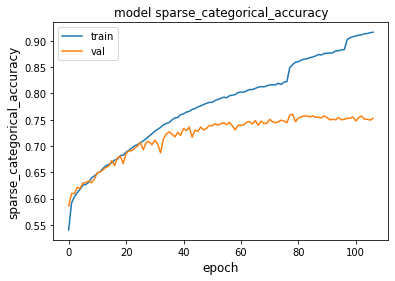

In [30]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

# Combine models